<a href="https://colab.research.google.com/github/9M3a1h3d9i9/Simulation_of_SIR-_SIS-_and_SIRS_models_on_a_Small_World_Network/blob/main/Simulation_of_SIR%2C_SIS%2C_and_SIRS_models_on_a_Small_World_Network(MmSh).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# بسم الله الرحمن الرحیم

### تمرین 4 ( امتیازی ) - محمد مهدی شفیقی

# Step 1: Import necessary libraries


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random


# Step 2: Define simulation parameters
# Network parameters

In [3]:
N = 500  # Number of nodes
K = 6    # Number of nearest neighbors for each node
P = 0.1  # Rewiring probability

# Epidemic parameters (assumed from question 3)
BETA = 0.3  # Infection rate
GAMMA = 0.5 # Recovery rate
LAMBDA = 0.2 # Waning immunity rate (for SIRS)

# Simulation parameters
INITIAL_INFECTED = 5  # Initial number of infected nodes
STEPS = 200           # Number of time steps for the simulation


# --- یادداشتی در مورد اعداد تصادفی ارائه شده ---

لیست 20 عدد تصادفی در قسمت، برای شبیه‌سازی کامل کافی نیست.
یک شبیه‌سازی تصادفی استاندارد به یک عدد تصادفی جدید برای هر رویداد احتمالی نیاز دارد.
بنابراین، ما از تابع

`random.random() `

در پایتون که در عمل استاندارد است، استفاده خواهیم کرد.

# Step 3: Create the Small-World network


In [4]:
G = nx.watts_strogatz_graph(n=N, k=K, p=P)

def run_epidemic_simulation(graph, model_type):
    """
    Runs a single epidemic simulation on a given graph.

    Args:
        graph (nx.Graph): The network to run the simulation on.
        model_type (str): The type of model to simulate ('SIR', 'SIS', 'SIRS').

    Returns:
        tuple: Lists containing the count of susceptible, infected, and recovered
               individuals at each time step.
    """
    # Initialize node states
    states = {node: 'S' for node in graph.nodes()}
    initial_nodes = random.sample(list(graph.nodes()), INITIAL_INFECTED)
    for node in initial_nodes:
        states[node] = 'I'

    # Lists to store the history of compartment sizes
    s_counts = []
    i_counts = []
    r_counts = []

    # Main simulation loop
    for step in range(STEPS):
        # Store counts for the current step
        s_counts.append(list(states.values()).count('S'))
        i_counts.append(list(states.values()).count('I'))
        r_counts.append(list(states.values()).count('R'))

        # To ensure simultaneous updates, we calculate the next state based on the current one
        next_states = states.copy()

        for node in graph.nodes():
            # --- Infection Logic ---
            if states[node] == 'S':
                infected_neighbors = 0
                for neighbor in graph.neighbors(node):
                    if states[neighbor] == 'I':
                        infected_neighbors += 1

                # Probability of getting infected
                prob_infection = 1 - (1 - BETA)**infected_neighbors
                if random.random() < prob_infection:
                    next_states[node] = 'I'

            # --- Recovery/State Change Logic ---
            elif states[node] == 'I':
                if random.random() < GAMMA:
                    if model_type == 'SIS':
                        next_states[node] = 'S'  # Recover and become susceptible
                    else: # SIR or SIRS
                        next_states[node] = 'R'  # Recover and become immune

            elif states[node] == 'R':
                if model_type == 'SIRS':
                    if random.random() < LAMBDA:
                        next_states[node] = 'S' # Lose immunity and become susceptible

        # Update the states for the next iteration
        states = next_states

    return s_counts, i_counts, r_counts


# Step 4: Run the simulation for each model & Plot the results


Running SIR simulation...
Running SIS simulation...
Running SIRS simulation...
Simulations complete. Plotting results...


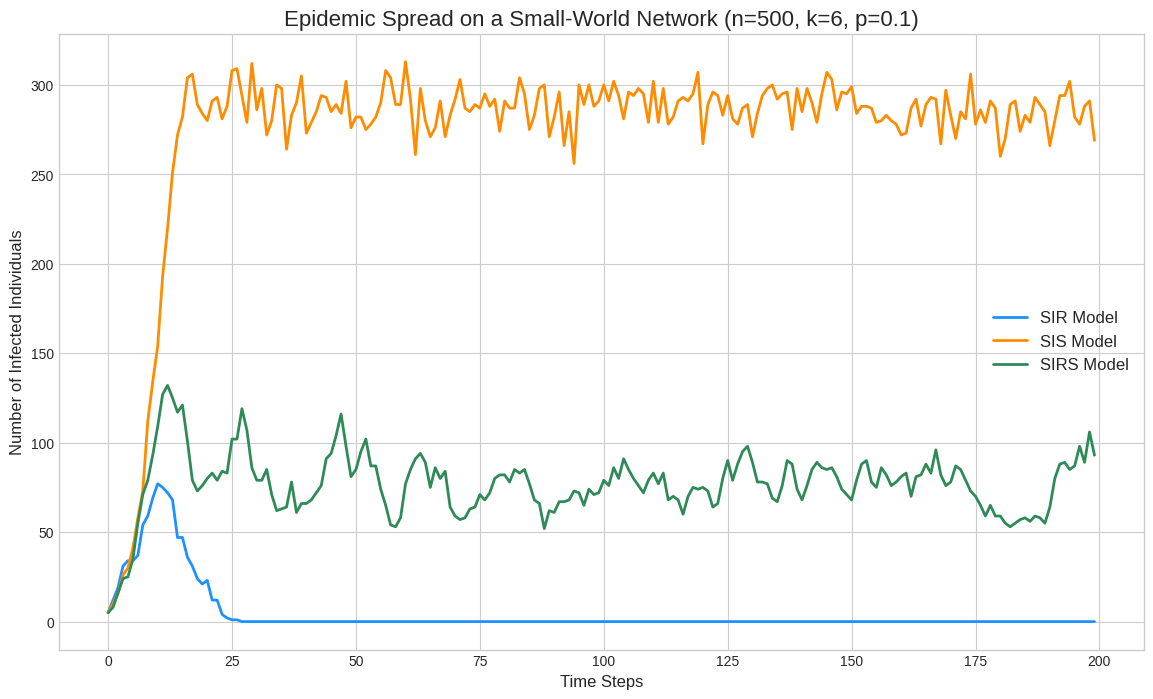

In [6]:
print("Running SIR simulation...")
s_sir, i_sir, r_sir = run_epidemic_simulation(G, 'SIR')

print("Running SIS simulation...")
s_sis, i_sis, r_sis = run_epidemic_simulation(G, 'SIS')

print("Running SIRS simulation...")
s_sirs, i_sirs, r_sirs = run_epidemic_simulation(G, 'SIRS')

print("Simulations complete. Plotting results...")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(i_sir, label='SIR Model', color='dodgerblue', linewidth=2)
ax.plot(i_sis, label='SIS Model', color='darkorange', linewidth=2)
ax.plot(i_sirs, label='SIRS Model', color='seagreen', linewidth=2)

ax.set_title('Epidemic Spread on a Small-World Network (n=500, k=6, p=0.1)', fontsize=16)
ax.set_xlabel('Time Steps', fontsize=12)
ax.set_ylabel('Number of Infected Individuals', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True)
plt.show()

# تأثیر بازگشت‌پذیری ایمنی را در مدل `SIRS`

بازگشت‌پذیری ایمنی

`(λ > 0)`

عامل تعیین‌کننده بقای بیماری در بلندمدت است. این پارامتر دینامیک سیستم را به طور کامل تغییر می‌دهد:

### `λ (مدل SIR)` `!` : اپیدمی یک رویداد گذرا و یک‌طرفه است که با مصرف منابعش پایان می‌یابد.

### `λ (مدل SIRS)`: اپیدمی به یک فرآیند چرخه‌ای و پایدار تبدیل می‌شود. بازگشت افراد از حالت مصون به مستعد، تضمین می‌کند که ویروس هرگز به طور کامل بدون میزبان نمی‌ماند. این ویژگی به بیماری اجازه می‌دهد تا حتی با قدرت سرایت پایین، به صورت نامحدود در جمعیت باقی بماند و خود را حفظ کند. در واقع، λ سیستم را از یک حالت "پایان‌پذیر" به یک حالت "تعادلی و پویا" تبدیل می‌کند.